# MinIO read throughput on Grid'5000

Data: `run-sweep-grid.py --mode s3` → `s3_sweep.py` → `s3grid/s3-grid.csv` (68 configurations: 11 partition sizes × 6 `max_parallel`).
Model (fitted in `minio_model.py`): aggregate throughput `A(k) = min(k·B1, Bmax / (1 + γk))`, k = functions reading at once.

In [4]:
GRID_DIR = "cost-report/tpch100-v5/s3grid"
OUT_NAME = "minio-g5k-agg"

## Style và dữ liệu

In [5]:
import os, csv, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from minio_model import fit, agg          # same fit as minio_model.py
%matplotlib inline

fm.fontManager.addfont("./fonts/LinLibertine_R.otf")
plt.rcParams['font.family'] = 'Linux Libertine O'
plt.rcParams['font.serif'] = ['Linux Libertine O']
FONT_SIZE = 13
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "mathtext.fontset": "custom", "mathtext.rm": "Linux Libertine O",
    "mathtext.it": "Linux Libertine O:italic", "axes.unicode_minus": True,
    "text.color": "black", "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
})
INK2, GRID, MODEL = "#52514e", "#e4e3df", "#eb6834"
DPI = 300


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(GRID_DIR, f"{name}.{ext}"), dpi=DPI, bbox_inches="tight", pad_inches=0.02)


rows = [{k: float(v) for k, v in r.items()} for r in csv.DictReader(open(os.path.join(GRID_DIR, "s3-grid.csv")))]
m = fit(rows)
b1, bmax, g = m["B1_MBps"], m["Bmax_MBps"], m["gamma"]
k_star = (-1 + np.sqrt(1 + 4 * g * bmax / b1)) / (2 * g) if g > 0 else bmax / b1
print(f"B1 = {b1:.0f} MB/s, Bmax = {bmax:.0f} MB/s, gamma = {g:.3f}, k* = {k_star:.1f}, "
      f"peak = {agg(k_star, b1, bmax, g) / 1024:.2f} GB/s, error agg {m['mape_agg_%']:.0f}% / per-fn {m['mape_fn_%']:.0f}%")

B1 = 234 MB/s, Bmax = 2403 MB/s, gamma = 0.013, k* = 9.2, peak = 2.10 GB/s, error agg 4% / per-fn 9%


## Hình: aggregate S3 read throughput (một cột)

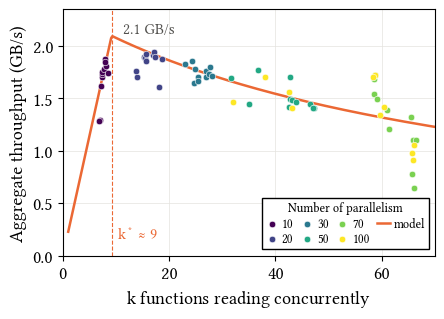

In [6]:
TITLE   = None          # None để bỏ
FIGSIZE = (4.8, 3.2)    # một cột
LEGEND  = True
XMAX    = 70
YMAX    = 2.35   # headroom for the peak label

mps = sorted({r["mp"] for r in rows})
cmap = plt.get_cmap("viridis", len(mps))
fig, ax = plt.subplots(figsize=FIGSIZE)
for i, mp in enumerate(mps):
    R = [r for r in rows if r["mp"] == mp]
    ax.scatter([r["readers"] for r in R], [r["agg_MBps"] / 1024 for r in R], s=22, color=cmap(i),
               edgecolor="white", lw=0.4, zorder=3, label=f"{int(mp)}")
k = np.linspace(1, XMAX, 300)
ax.plot(k, agg(k, b1, bmax, g) / 1024, color=MODEL, lw=1.8, zorder=2, label="model")
ax.axvline(k_star, color=MODEL, lw=0.8, ls="--", zorder=1)
ax.annotate(f"$k^*$ ≈ {k_star:.0f}", (k_star, 0.15), xytext=(4, 0), textcoords="offset points",
            color=MODEL, fontsize=FONT_SIZE - 2)
ax.annotate(f"{agg(k_star, b1, bmax, g) / 1024:.1f} GB/s", (k_star, agg(k_star, b1, bmax, g) / 1024),
            xytext=(8, 2), textcoords="offset points", color=INK2, fontsize=FONT_SIZE - 2)
ax.set_xlim(0, XMAX)
ax.set_ylim(0, YMAX)
ax.set_xlabel("$k$ functions reading concurrently")
ax.set_ylabel("Aggregate throughput (GB/s)")
ax.grid(True, color=GRID)
ax.set_axisbelow(True)
if TITLE:
    ax.set_title(TITLE, loc="left")
if LEGEND:
    ax.legend(title="Number of parallelism", title_fontsize=FONT_SIZE - 4, fontsize=FONT_SIZE - 4, ncol=4, loc="lower right",
              frameon=True, edgecolor="black", fancybox=False, framealpha=1, borderpad=0.3, labelspacing=0.2,
              handlelength=1.0, handletextpad=0.3, columnspacing=0.6)
save(fig, OUT_NAME)